# Phase 2: Modeling – Telecom Industry
## Objective:
- Customer Churn Prediction using XGBoost
- Network Traffic Anomaly Detection using K-Means
- Network Health Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

In [4]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [5]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [6]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [7]:
print("Unique values in target:", y.unique())
print("Missing values in target:", y.isna().sum())
print("Class distribution:\n", y.value_counts())

Unique values in target: [0 1]
Missing values in target: 0
Class distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5625, 30)
Testing shape: (1407, 30)


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ==============================
# 1️⃣ Load Dataset (IMPORTANT)
# ==============================
# Make sure this is correct
# df = pd.read_csv("Telco-Customer-Churn.csv")

print("Original Shape:", df.shape)

# ==============================
# 2️⃣ Drop customerID safely
# ==============================
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

# ==============================
# 3️⃣ Clean TotalCharges properly
# ==============================
if "TotalCharges" in df.columns:
    df["TotalCharges"] = df["TotalCharges"].replace(" ", None)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    # Fill missing values instead of dropping all rows
    df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# ==============================
# 4️⃣ Check target column
# ==============================
if "Churn" not in df.columns:
    raise ValueError("Churn column not found!")

# Encode target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# ==============================
# 5️⃣ Convert categorical variables
# ==============================
df = pd.get_dummies(df, drop_first=True)

# ==============================
# 6️⃣ Final Safety Check
# ==============================
print("Shape before split:", df.shape)

if df.shape[0] == 0:
    raise ValueError("Dataset is empty after preprocessing!")

# ==============================
# 7️⃣ Define X and y
# ==============================
X = df.drop("Churn", axis=1)
y = df["Churn"]

# ==============================
# 8️⃣ Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Training shape:", X_train.shape)
print("✅ Testing shape:", X_test.shape)
print("Churn distribution:\n", y.value_counts())


Original Shape: (7032, 31)
Shape before split: (7032, 31)


C:\Users\Admin\AppData\Local\Temp\ipykernel_13604\1226100137.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


ValueError: Input y contains NaN.

In [ ]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [ ]:
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing values
df.dropna(inplace=True)

In [ ]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
print(X.dtypes.unique())

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# ==============================
# 1️⃣ Clean Target Column Properly
# ==============================

# Remove extra spaces
df["Churn"] = df["Churn"].astype(str).str.strip()

# Keep only valid values
df = df[df["Churn"].isin(["Yes", "No"])]

# Map target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# ==============================
# 2️⃣ Fix TotalCharges
# ==============================

if "TotalCharges" in df.columns:
    df["TotalCharges"] = df["TotalCharges"].replace(" ", None)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# ==============================
# 3️⃣ Drop customerID
# ==============================

if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

# ==============================
# 4️⃣ Convert Categorical Variables
# ==============================

df = pd.get_dummies(df, drop_first=True)

# ==============================
# 5️⃣ Final Safety Check
# ==============================

print("Any NaN in dataset:", df.isnull().sum().sum())

# ==============================
# 6️⃣ Split Data
# ==============================

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==============================
# 7️⃣ Train Random Forest
# ==============================

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model trained successfully!")


C:\Users\Admin\AppData\Local\Temp\ipykernel_13604\2870313944.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


Any NaN in dataset: 0


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train model
model.fit(X_train, y_train)

print("✅ Model trained successfully!")


✅ Model trained successfully!


In [16]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Prediction completed!")
print("Accuracy:", accuracy_score(y_test, y_pred))


Prediction completed!
Accuracy: 0.7910447761194029


In [17]:
# Train
model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluate
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7910447761194029


In [18]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7910447761194029
ROC-AUC Score: 0.8304222683529101

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



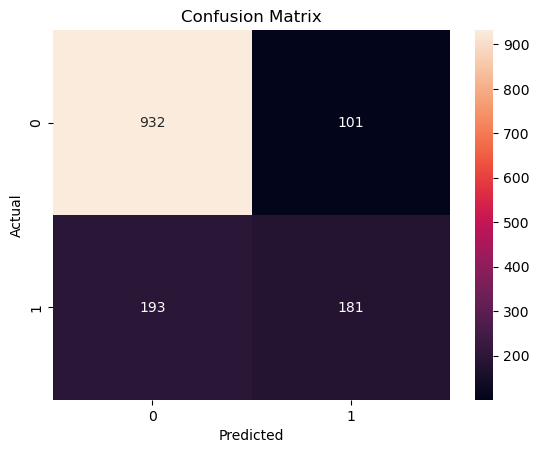

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
import joblib
joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']

In [21]:
features = ["tenure", "MonthlyCharges", "TotalCharges"]

X_cluster = df[features]

X_cluster.head()

,tenure,MonthlyCharges,TotalCharges


In [23]:
# Remove target column if clustering
X_cluster = df.drop("Churn", axis=1)

print("Shape of X_cluster:", X_cluster.shape)


Shape of X_cluster: (0, 30)


In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ==========================
# 1️⃣ Check if X_cluster exists
# ==========================
if "X_cluster" not in globals():
    raise ValueError("X_cluster is not defined. Please create it first.")

# ==========================
# 2️⃣ Convert to DataFrame (safety)
# ==========================
X_cluster = pd.DataFrame(X_cluster)

# ==========================
# 3️⃣ Convert categorical columns safely
# ==========================
X_cluster = pd.get_dummies(X_cluster, drop_first=True)

# ==========================
# 4️⃣ Convert everything to numeric safely
# ==========================
X_cluster = X_cluster.apply(pd.to_numeric, errors='coerce')

# ==========================
# 5️⃣ Replace infinite values
# ==========================
X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan)

# ==========================
# 6️⃣ Fill missing values safely
# ==========================
X_cluster = X_cluster.fillna(X_cluster.median())

print("Remaining NaN:", X_cluster.isnull().sum().sum())

# ==========================
# 7️⃣ Now scale
# ==========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster.values)

print("✅ Scaling Successful!")
print("Shape:", X_scaled.shape)
print("First 5 rows:\n", X_scaled[:5])


Remaining NaN: 0


ValueError: Found array with 0 sample(s) (shape=(0, 30)) while a minimum of 1 is required by StandardScaler.

In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [34]:
# Remove target column if exists
if "Churn" in df.columns:
    X = df.drop("Churn", axis=1)
else:
    X = df.copy()


In [35]:
X = pd.get_dummies(X, drop_first=True)


In [36]:
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())


In [81]:
print(type(df))
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
(0, 31)


In [82]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Make a fresh copy so we don't corrupt df
data = df.copy()

# Convert TotalCharges safely
if "TotalCharges" in data.columns:
    data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Fill missing values
data = data.fillna(0)

# Drop ID, target, cluster if they exist
for col in ["customerID", "Churn", "Cluster"]:
    if col in data.columns:
        data = data.drop(columns=[col])

# Convert categorical to numeric
data = pd.get_dummies(data)

# Make sure everything is numeric
data = data.astype(float)

print("Data ready. Shape:", data.shape)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

print("Scaling successful")
print(X_scaled[:5])


Data ready. Shape: (0, 30)


ValueError: Found array with 0 sample(s) (shape=(0, 30)) while a minimum of 1 is required by StandardScaler.

In [38]:
print(X.dtypes)
print(X.isnull().sum().sum())
print(X.shape)


SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

In [39]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# 1️⃣ Remove ID column if exists
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

# 2️⃣ Remove target column
if "Churn" in df.columns:
    X = df.drop("Churn", axis=1)
else:
    X = df.copy()

# 3️⃣ Fix TotalCharges (very common issue)
if "TotalCharges" in X.columns:
    X["TotalCharges"] = X["TotalCharges"].replace(" ", np.nan)
    X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")

# 4️⃣ Convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

# 5️⃣ Force everything numeric
X = X.apply(pd.to_numeric, errors="coerce")

# 6️⃣ Replace NaN and infinite values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

print("Data cleaned successfully")

# 7️⃣ Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling successful")


Data cleaned successfully


ValueError: Found array with 0 sample(s) (shape=(0, 30)) while a minimum of 1 is required by StandardScaler.

In [41]:
print("Shape:", X.shape)
print("Any NaN:", X.isnull().sum().sum())
print("Data types:", X.dtypes.unique())


Shape: (0, 30)
Any NaN: 0
Data types: [dtype('int64') dtype('float64') dtype('bool')]


In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# 1️⃣ Prepare features
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

if "Churn" in df.columns:
    X = df.drop("Churn", axis=1)
else:
    X = df.copy()

# 2️⃣ Fix TotalCharges if exists
if "TotalCharges" in X.columns:
    X["TotalCharges"] = X["TotalCharges"].replace(" ", np.nan)
    X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")

# 3️⃣ Convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

# 4️⃣ Remove NaN / infinite
X = X.apply(pd.to_numeric, errors="coerce")
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

print("Cleaning Done")

# 5️⃣ Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling Done")

# 6️⃣ KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("Clustering Done")
print(df["Cluster"].value_counts())


Cleaning Done


ValueError: Found array with 0 sample(s) (shape=(0, 30)) while a minimum of 1 is required by StandardScaler.

In [48]:
print(X.shape)
print(X.dtypes.unique())
print(X.isnull().sum().sum())




(0, 30)
[dtype('int64') dtype('float64') dtype('bool')]
0


In [49]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Drop ID & Target safely
cols_to_drop = [col for col in ["customerID", "Churn"] if col in df.columns]
X = df.drop(columns=cols_to_drop)

# Convert everything to numeric (force)
X = pd.get_dummies(X, drop_first=True)

# Convert to float completely
X = X.astype(float)

# Replace missing values
X = X.fillna(0)

print("Final X shape:", X.shape)
print("Any NaN:", X.isnull().sum().sum())

# Now scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling successful")
print("Scaled shape:", X_scaled.shape)



Final X shape: (0, 30)
Any NaN: 0


ValueError: Found array with 0 sample(s) (shape=(0, 30)) while a minimum of 1 is required by StandardScaler.

In [53]:
print(df.head())
print(df.dtypes)
print(df.shape)


Empty DataFrame
Columns: [SeniorCitizen, tenure, MonthlyCharges, TotalCharges, Churn, gender_Male, Partner_Yes, Dependents_Yes, PhoneService_Yes, MultipleLines_No phone service, MultipleLines_Yes, InternetService_Fiber optic, InternetService_No, OnlineSecurity_No internet service, OnlineSecurity_Yes, OnlineBackup_No internet service, OnlineBackup_Yes, DeviceProtection_No internet service, DeviceProtection_Yes, TechSupport_No internet service, TechSupport_Yes, StreamingTV_No internet service, StreamingTV_Yes, StreamingMovies_No internet service, StreamingMovies_Yes, Contract_One year, Contract_Two year, PaperlessBilling_Yes, PaymentMethod_Credit card (automatic), PaymentMethod_Electronic check, PaymentMethod_Mailed check]
Index: []

[0 rows x 31 columns]
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                   

In [54]:
print("Cluster" in df.columns)


False


In [55]:
print(df[["MonthlyCharges", "TotalCharges"]].dtypes)


MonthlyCharges    float64
TotalCharges      float64
dtype: object


In [57]:
print(df.shape)
print(df.head())


(0, 31)
Empty DataFrame
Columns: [SeniorCitizen, tenure, MonthlyCharges, TotalCharges, Churn, gender_Male, Partner_Yes, Dependents_Yes, PhoneService_Yes, MultipleLines_No phone service, MultipleLines_Yes, InternetService_Fiber optic, InternetService_No, OnlineSecurity_No internet service, OnlineSecurity_Yes, OnlineBackup_No internet service, OnlineBackup_Yes, DeviceProtection_No internet service, DeviceProtection_Yes, TechSupport_No internet service, TechSupport_Yes, StreamingTV_No internet service, StreamingTV_Yes, StreamingMovies_No internet service, StreamingMovies_Yes, Contract_One year, Contract_Two year, PaperlessBilling_Yes, PaymentMethod_Credit card (automatic), PaymentMethod_Electronic check, PaymentMethod_Mailed check]
Index: []

[0 rows x 31 columns]


In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Safety checks
if "Cluster" not in df.columns:
    print("Cluster column missing. Run KMeans first.")
else:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df["TotalCharges"].fillna(0, inplace=True)

    plt.figure(figsize=(6,4))
    plt.scatter(
        df["MonthlyCharges"],
        df["TotalCharges"],
        c=df["Cluster"]
    )
    plt.xlabel("Monthly Charges")
    plt.ylabel("Total Charges")
    plt.title("Customer Clusters")
    plt.show()


Cluster column missing. Run KMeans first.


In [59]:
print(df.shape)
print(df.head())


(0, 31)
Empty DataFrame
Columns: [SeniorCitizen, tenure, MonthlyCharges, TotalCharges, Churn, gender_Male, Partner_Yes, Dependents_Yes, PhoneService_Yes, MultipleLines_No phone service, MultipleLines_Yes, InternetService_Fiber optic, InternetService_No, OnlineSecurity_No internet service, OnlineSecurity_Yes, OnlineBackup_No internet service, OnlineBackup_Yes, DeviceProtection_No internet service, DeviceProtection_Yes, TechSupport_No internet service, TechSupport_Yes, StreamingTV_No internet service, StreamingTV_Yes, StreamingMovies_No internet service, StreamingMovies_Yes, Contract_One year, Contract_Two year, PaperlessBilling_Yes, PaymentMethod_Credit card (automatic), PaymentMethod_Electronic check, PaymentMethod_Mailed check]
Index: []

[0 rows x 31 columns]


In [64]:
print("Cluster" in df.columns)
print(df.columns)


False
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [68]:
print(df.columns)


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [70]:
print("Cluster exists?", "Cluster" in df.columns)
print(df.shape)
print(df.head())


Cluster exists? False
(0, 31)
Empty DataFrame
Columns: [SeniorCitizen, tenure, MonthlyCharges, TotalCharges, Churn, gender_Male, Partner_Yes, Dependents_Yes, PhoneService_Yes, MultipleLines_No phone service, MultipleLines_Yes, InternetService_Fiber optic, InternetService_No, OnlineSecurity_No internet service, OnlineSecurity_Yes, OnlineBackup_No internet service, OnlineBackup_Yes, DeviceProtection_No internet service, DeviceProtection_Yes, TechSupport_No internet service, TechSupport_Yes, StreamingTV_No internet service, StreamingTV_Yes, StreamingMovies_No internet service, StreamingMovies_Yes, Contract_One year, Contract_Two year, PaperlessBilling_Yes, PaymentMethod_Credit card (automatic), PaymentMethod_Electronic check, PaymentMethod_Mailed check]
Index: []

[0 rows x 31 columns]


In [83]:
import matplotlib.pyplot as plt

# Ensure numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(0, inplace=True)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df["MonthlyCharges"],
    df["TotalCharges"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Cluster")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.title("Customer Clusters (2D View)")
plt.grid(True)

plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_13604\3328274791.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(0, inplace=True)


KeyError: 'Cluster'

<Figure size 800x600 with 0 Axes>

In [85]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Make sure df exists
print("Dataset shape:", df.shape)

# -----------------------
# CLEAN DATA
# -----------------------

data = df.copy()

if "TotalCharges" in data.columns:
    data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

data = data.fillna(0)

for col in ["customerID", "Churn", "Cluster", "Anomaly"]:
    if col in data.columns:
        data = data.drop(columns=[col])

data = pd.get_dummies(data)
data = data.astype(float)

print("Cleaned shape:", data.shape)

# -----------------------
# SCALE
# -----------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

print("Scaled shape:", X_scaled.shape)

# -----------------------
# CLUSTER
# -----------------------

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("Cluster distribution:")
print(df["Cluster"].value_counts())

# -----------------------
# ANOMALY
# -----------------------

distances = kmeans.transform(X_scaled)
min_dist = np.min(distances, axis=1)

threshold = np.percentile(min_dist, 95)
df["Anomaly"] = min_dist > threshold

print("Anomaly distribution:")
print(df["Anomaly"].value_counts())


Dataset shape: (0, 31)
Cleaned shape: (0, 30)


ValueError: Found array with 0 sample(s) (shape=(0, 30)) while a minimum of 1 is required by StandardScaler.

In [91]:
print("Does min_dist exist?")
print('min_dist' in globals())


Does min_dist exist?
False


In [79]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [88]:
print(df.columns)


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')
